## Import Packages

In [1]:
import os
import numpy as np
import scipy as sp
import pandas as pd
import seaborn as sns
from PIL import Image
import tensorflow as tf
import keras_cv
from tensorflow.data import AUTOTUNE
import tensorflow.keras as keras
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (
    RandomBrightness, RandomZoom, RandomFlip,
    Input, Conv2D, BatchNormalization, MaxPool2D, Dropout, Flatten, Dense
)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Using TensorFlow backend


## Load the Preprocessed dataset

In [2]:
X_loaded = np.load('/kaggle/input/alzheimer/X_final.npy')
Y_loaded = np.load('/kaggle/input/alzheimer/Y_final.npy')

In [3]:
# Reshape the grayscale data to (num_samples, height, width, channels)
X_loaded_resized = np.resize(X_loaded, (len(X_loaded), 150, 150, 1))

# Replicate the single channel to create three channels
X_loaded_rgb = np.repeat(X_loaded_resized, 3, axis=-1)

In [4]:
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_loaded_rgb, Y_loaded, random_state=42)
X_train.shape

(6400, 150, 150, 3)

In [5]:
mean = np.mean(X_train)
std = np.std(X_train)

X_train = ((X_train - mean) / std).astype(np.float32)

## Split the dataset into training and testing dataset

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [7]:
print("Number of samples in X_train:", X_train.shape[0])
print("Number of samples in X_test:", X_test.shape[0])


Number of samples in X_train: 5120
Number of samples in X_test: 1280


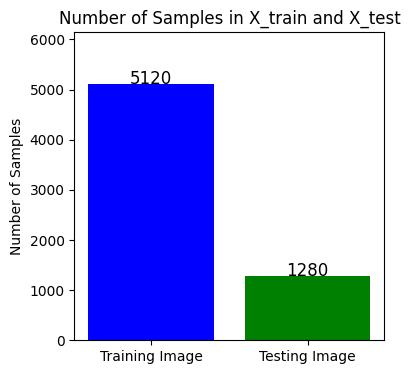

In [8]:
# Calculate the number of samples in X_train and X_test
train_samples = X_train.shape[0]
test_samples = X_test.shape[0]

# Creating bars
labels = ['Training Image', 'Testing Image']
samples = [train_samples, test_samples]

plt.figure(figsize=(4, 4))

# Creating the bar plot
plt.bar(labels, samples, color=['blue', 'green'])

# Adding the count on top of each bar
for i, sample in enumerate(samples):
    plt.text(i, sample + 0.1, str(sample), ha='center', fontsize=12)

# Adding labels and title
plt.ylabel('Number of Samples')
plt.title('Number of Samples in X_train and X_test')
plt.ylim(0, max(samples) * 1.2)  # Set ylim for better visualization

# Show plot
plt.show()

## Import Keras Input, layers and model

In [9]:
from keras import Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense, BatchNormalization,concatenate
from keras.models import Model

## Training Data Augmentation

In [10]:
datagen = keras.preprocessing.image.ImageDataGenerator(
featurewise_center=False,
samplewise_center=False,
featurewise_std_normalization=False,
samplewise_std_normalization=False,
zca_whitening=False,
rotation_range=10,
zoom_range=0.2,
width_shift_range=0.2,
horizontal_flip=False,
vertical_flip=False)

datagen.fit(X_train)

## ADNET - our proposed model

In [11]:
# Define the input layer
visible = Input(shape=(150, 150, 3))

# Block 1
conv1_1 = Conv2D(64, kernel_size=3, activation='relu')(visible)
pool1_1 = MaxPooling2D(pool_size=(2, 2))(conv1_1)

conv1_2 = Conv2D(128, kernel_size=3, activation='relu')(pool1_1)
pool1_2 = MaxPooling2D(pool_size=(2, 2))(conv1_2)

conv1_3 = Conv2D(128, kernel_size=3, activation='relu')(pool1_2)
pool1_3 = MaxPooling2D(pool_size=(2, 2))(conv1_3)

conv1_4 = Conv2D(256, kernel_size=3, activation='relu')(pool1_3)
pool1_4 = MaxPooling2D(pool_size=(2, 2))(conv1_4)
batch_norm_1 = BatchNormalization()(pool1_4)

flat1 = Flatten()(batch_norm_1)

# Block 2
conv2_1 = Conv2D(64, kernel_size=3, activation='relu')(visible)
pool2_1 = MaxPooling2D(pool_size=(2, 2))(conv2_1)

conv2_2 = Conv2D(128, kernel_size=3, activation='relu')(pool2_1)
pool2_2 = MaxPooling2D(pool_size=(2, 2))(conv2_2)

conv2_3 = Conv2D(128, kernel_size=3, activation='relu')(pool2_2)
pool2_3 = MaxPooling2D(pool_size=(2, 2))(conv2_3)

conv2_4 = Conv2D(256, kernel_size=3, activation='relu')(pool2_3)
pool2_4 = MaxPooling2D(pool_size=(2, 2))(conv2_4)
batch_norm_2 = BatchNormalization()(pool2_4)

flat2 = Flatten()(batch_norm_2)

# Block 3
conv3_1 = Conv2D(64, kernel_size=3, activation='relu')(visible)
pool3_1 = MaxPooling2D(pool_size=(2, 2))(conv3_1)

conv3_2 = Conv2D(128, kernel_size=3, activation='relu')(pool3_1)
pool3_2 = MaxPooling2D(pool_size=(2, 2))(conv3_2)

conv3_3 = Conv2D(128, kernel_size=3, activation='relu')(pool3_2)
pool3_3 = MaxPooling2D(pool_size=(2, 2))(conv3_3)

conv3_4 = Conv2D(256, kernel_size=3, activation='relu')(pool3_3)
pool3_4 = MaxPooling2D(pool_size=(2, 2))(conv3_4)
batch_norm_3 = BatchNormalization()(pool3_4)

flat3 = Flatten()(batch_norm_3)

# Block 4
conv4_1 = Conv2D(64, kernel_size=3, activation='relu')(visible)
pool4_1 = MaxPooling2D(pool_size=(2, 2))(conv4_1)

conv4_2 = Conv2D(128, kernel_size=3, activation='relu')(pool4_1)
pool4_2 = MaxPooling2D(pool_size=(2, 2))(conv4_2)

conv4_3 = Conv2D(128, kernel_size=3, activation='relu')(pool4_2)
pool4_3 = MaxPooling2D(pool_size=(2, 2))(conv4_3)

conv4_4 = Conv2D(256, kernel_size=3, activation='relu')(pool4_3)
pool4_4 = MaxPooling2D(pool_size=(2, 2))(conv4_4)
batch_norm_4 = BatchNormalization()(pool4_4)

flat4 = Flatten()(batch_norm_4)

# # Merge the outputs of the convolutional blocks
merge = concatenate([flat1, flat2, flat3, flat4])
dropout_layer_1 = Dropout(0.25)(merge)

# Add a fully connected layer
hidden1 = Dense(512, activation='relu')(dropout_layer_1)
dropout_layer_3 = Dropout(0.5)(hidden1)

## Output layer
output = Dense(4, activation='softmax')(dropout_layer_3)

## Define the model
model = Model(inputs = visible, outputs=output)

## compile the model using Adam optimizer

In [12]:
# Compile the model
optimizer = tf.keras.optimizers.legacy.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=0.1, decay=0.0)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

/opt/conda/lib/python3.10/site-packages/keras/src/optimizers/legacy/adam.py:118: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


## Train the model

In [13]:
from keras.callbacks import ReduceLROnPlateau, TensorBoard, ModelCheckpoint

reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.8, patience=10)
tensorboard = TensorBoard(log_dir='logs')
checkpoint = ModelCheckpoint("/kaggle/working/alzheimers_cnn_ensemble.h5", monitor='val_accuracy',
    save_best_only=True, mode='auto', verbose=1)

history = model.fit(
    X_train,y_train, epochs =150, verbose=1, batch_size=32, validation_split=0.2
    , callbacks=[tensorboard,checkpoint,reduce_lr])

Epoch 1/150
128/128 [==============================] - ETA: 0s - loss: 1.1150 - accuracy: 0.5154
Epoch 1: val_accuracy improved from -inf to 0.58398, saving model to /kaggle/working/alzheimers_cnn_ensemble.h5


/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


128/128 [==============================] - 16s 102ms/step - loss: 1.1150 - accuracy: 0.5154 - val_loss: 1.2260 - val_accuracy: 0.5840 - lr: 0.0010
Epoch 2/150
128/128 [==============================] - ETA: 0s - loss: 0.8971 - accuracy: 0.5715
Epoch 2: val_accuracy improved from 0.58398 to 0.60254, saving model to /kaggle/working/alzheimers_cnn_ensemble.h5
128/128 [==============================] - 12s 95ms/step - loss: 0.8971 - accuracy: 0.5715 - val_loss: 1.1481 - val_accuracy: 0.6025 - lr: 0.0010
Epoch 3/150
128/128 [==============================] - ETA: 0s - loss: 0.8498 - accuracy: 0.5957
Epoch 3: val_accuracy improved from 0.60254 to 0.61133, saving model to /kaggle/working/alzheimers_cnn_ensemble.h5
128/128 [==============================] - 12s 96ms/step - loss: 0.8498 - accuracy: 0.5957 - val_loss: 0.9541 - val_accuracy: 0.6113 - lr: 0.0010
Epoch 4/150
128/128 [==============================] - ETA: 0s - loss: 0.7740 - accuracy: 0.6438
Epoch 4: val_accuracy improved from 0.61

## Accuracy and Validation Accuracy Curve

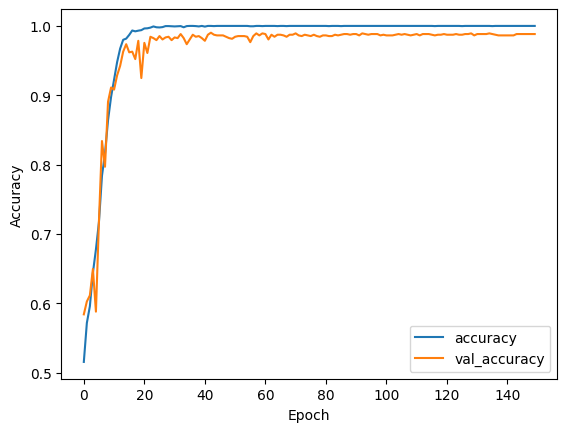

In [14]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Clasification Report

In [15]:
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

from sklearn.metrics import confusion_matrix, classification_report

# Predict on validation data
y_pred = model.predict(X_test)

# Convert predictions and true labels back from one-hot encoding
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

classificationReports = classification_report(y_true_classes, y_pred_classes, target_names=class_names)
print("Classification Report:")
print(classificationReports)

40/40 [==============================] - 1s 23ms/step
Classification Report:
                  precision    recall  f1-score   support

    MildDemented       1.00      0.98      0.99       160
ModerateDemented       1.00      1.00      1.00        11
     NonDemented       0.98      1.00      0.99       633
VeryMildDemented       0.99      0.98      0.98       476

        accuracy                           0.99      1280
       macro avg       0.99      0.99      0.99      1280
    weighted avg       0.99      0.99      0.99      1280



## Accuracy of the Model

In [16]:
from sklearn.metrics import accuracy_score

# Calculate accuracy using accuracy_score
acc = accuracy_score(y_true_classes, y_pred_classes)
print("Accuracy:", acc)

Accuracy: 0.9875


## Confusion Matrix

### Print the Confusion Matrix

In [17]:
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[157   0   1   2]
 [  0  11   0   0]
 [  0   0 631   2]
 [  0   0  11 465]]


### Visualize the Confusion Matrix

Confusion matrix, without normalization


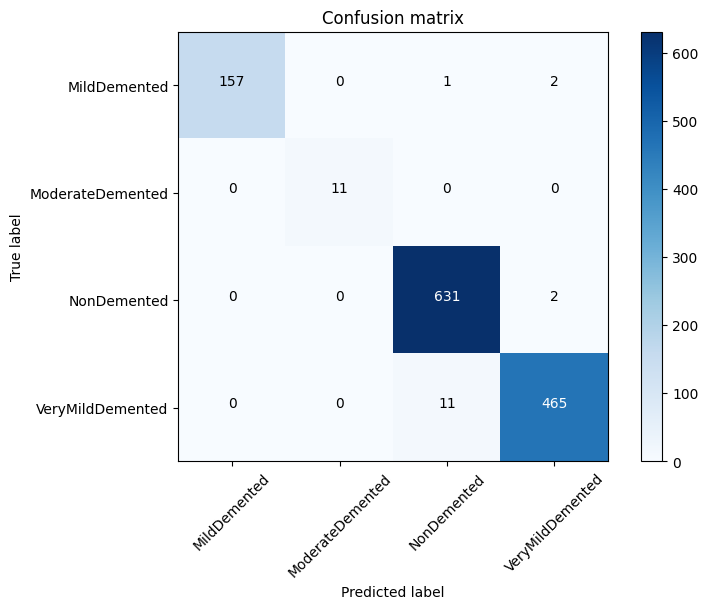

In [18]:
import itertools

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plot_confusion_matrix(conf_matrix, classes=class_names, normalize=False, title='Confusion matrix')
plt.show()

## Accuracy and Loss Curve

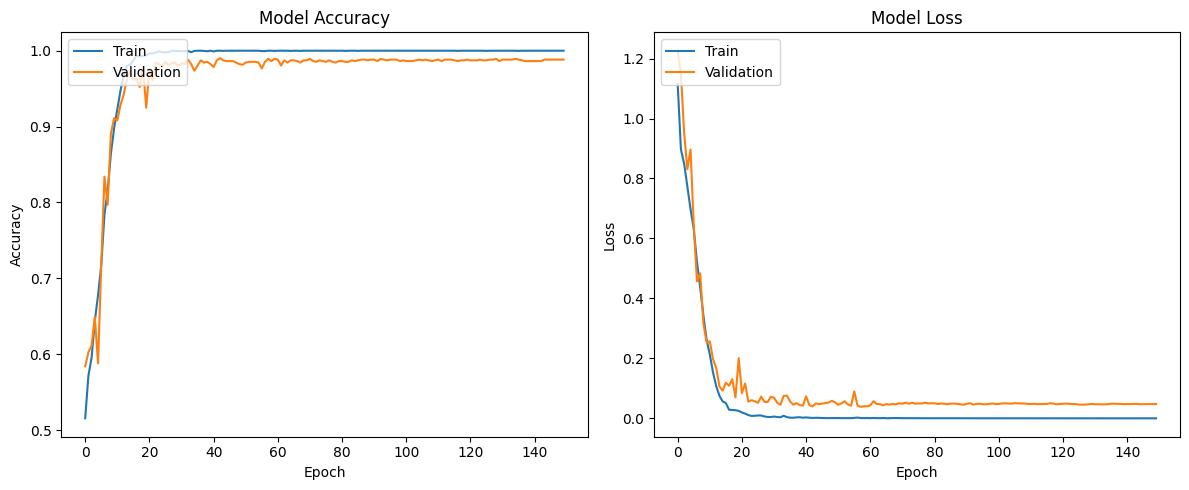

In [19]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## AUC-ROC Curve

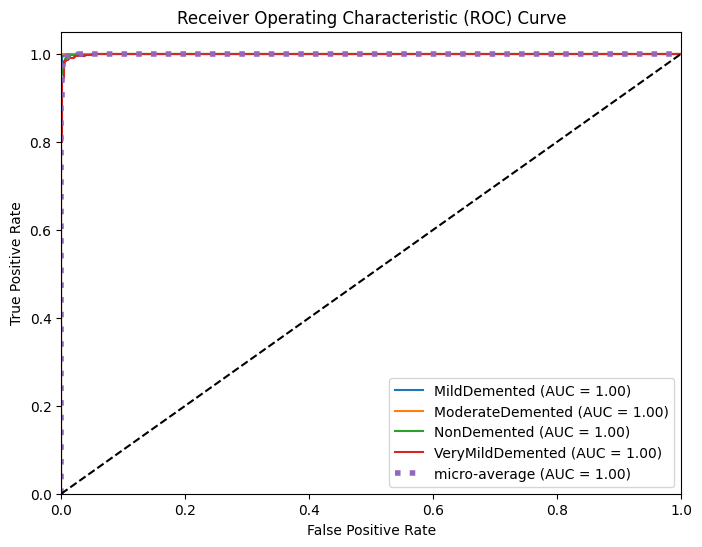

AUC-ROC (MildDemented): 0.9999
AUC-ROC (ModerateDemented): 1.0000
AUC-ROC (NonDemented): 0.9995
AUC-ROC (VeryMildDemented): 0.9992
AUC-ROC (micro-average): 0.9997


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score, auc

# Compute ROC curve and ROC area for each class
n_classes = len(class_names)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[class_names[i]] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_pred.ravel())
roc_auc['micro-average'] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[class_names[i]]:.2f})')

plt.plot(fpr["micro"], tpr["micro"], label='micro-average (AUC = {0:0.2f})'.format(roc_auc['micro-average']), linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--')  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Display AUC-ROC values
for class_name, auc_value in roc_auc.items():
    print(f'AUC-ROC ({class_name}): {auc_value:.4f}')


## Recal(Sensitivity), Precision, F-1 Score

In [21]:
# Calculate True Positives, False Positives, False Negatives for each class
tp = np.diag(conf_matrix)
fp = np.sum(conf_matrix, axis=0) - tp
fn = np.sum(conf_matrix, axis=1) - tp
# Calculate True Negatives (TN) for each class
tn = []
for i in range(len(conf_matrix)):
    temp = np.delete(conf_matrix, i, 0)  # Remove ith row
    temp = np.delete(temp, i, 1)  # Remove ith column
    tn.append(np.sum(temp))

# Calculate Recall, Precision, and F1-score for each class
recall = tp / (tp + fn)
precision = tp / (tp + fp)
f1_score = 2 * (precision * recall) / (precision + recall)

# Calculate average Recall, Precision, and F1-score
macro_avg_recall = np.mean(recall)
macro_avg_precision = np.mean(precision)
macro_avg_f1_score = np.mean(f1_score)

print(f"Macro-average Recall: {macro_avg_recall:.4f}")
print(f"Macro-average Precision: {macro_avg_precision:.4f}")
print(f"Macro-average F1-score: {macro_avg_f1_score:.4f}")

Macro-average Recall: 0.9887
Macro-average Precision: 0.9932
Macro-average F1-score: 0.9909


## Specificity & G-Mean score

In [22]:
# Calculate True Negatives for each class
tn = np.sum(conf_matrix) - (fp + fn + tp)

# Calculate Sensitivity (Recall) for each class
sensitivity = tp / (tp + fn)

# Calculate Specificity for each class
specificity = tn / (tn + fp)

# Calculate G-Mean for each class
g_mean = np.sqrt(sensitivity * specificity)

# Calculate average Sensitivity, Specificity, and G-Mean
avg_specificity = np.mean(specificity)
avg_g_mean = np.mean(g_mean)

print(f"Average Specificity: {avg_specificity:.4f}")
print(f"Average G-Mean: {avg_g_mean:.4f}")

Average Specificity: 0.9941
Average G-Mean: 0.9914


## MCC

In [23]:
def matthews_corr_coefficient(tp, tn, fp, fn):
    numerator = (tp * tn) - (fp * fn)
    denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = numerator / denominator if denominator != 0 else 0  # Handle division by zero
    return mcc

# Calculate MCC for each class against the rest
mcc_per_class = []
for i in range(len(tp)):
    tp_i, tn_i = tp[i], np.sum(np.delete(tp, i))  # True positives and true negatives for class i
    fp_i, fn_i = fp[i], np.sum(np.delete(fp, i))  # False positives and false negatives for class i
    
    mcc_i = matthews_corr_coefficient(tp_i, tn_i, fp_i, fn_i)
    mcc_per_class.append(mcc_i)

# Calculate average MCC across all classes
mcc_avg = np.mean(mcc_per_class)
print("Average MCC:", mcc_avg)

Average MCC: 0.8821030305699175


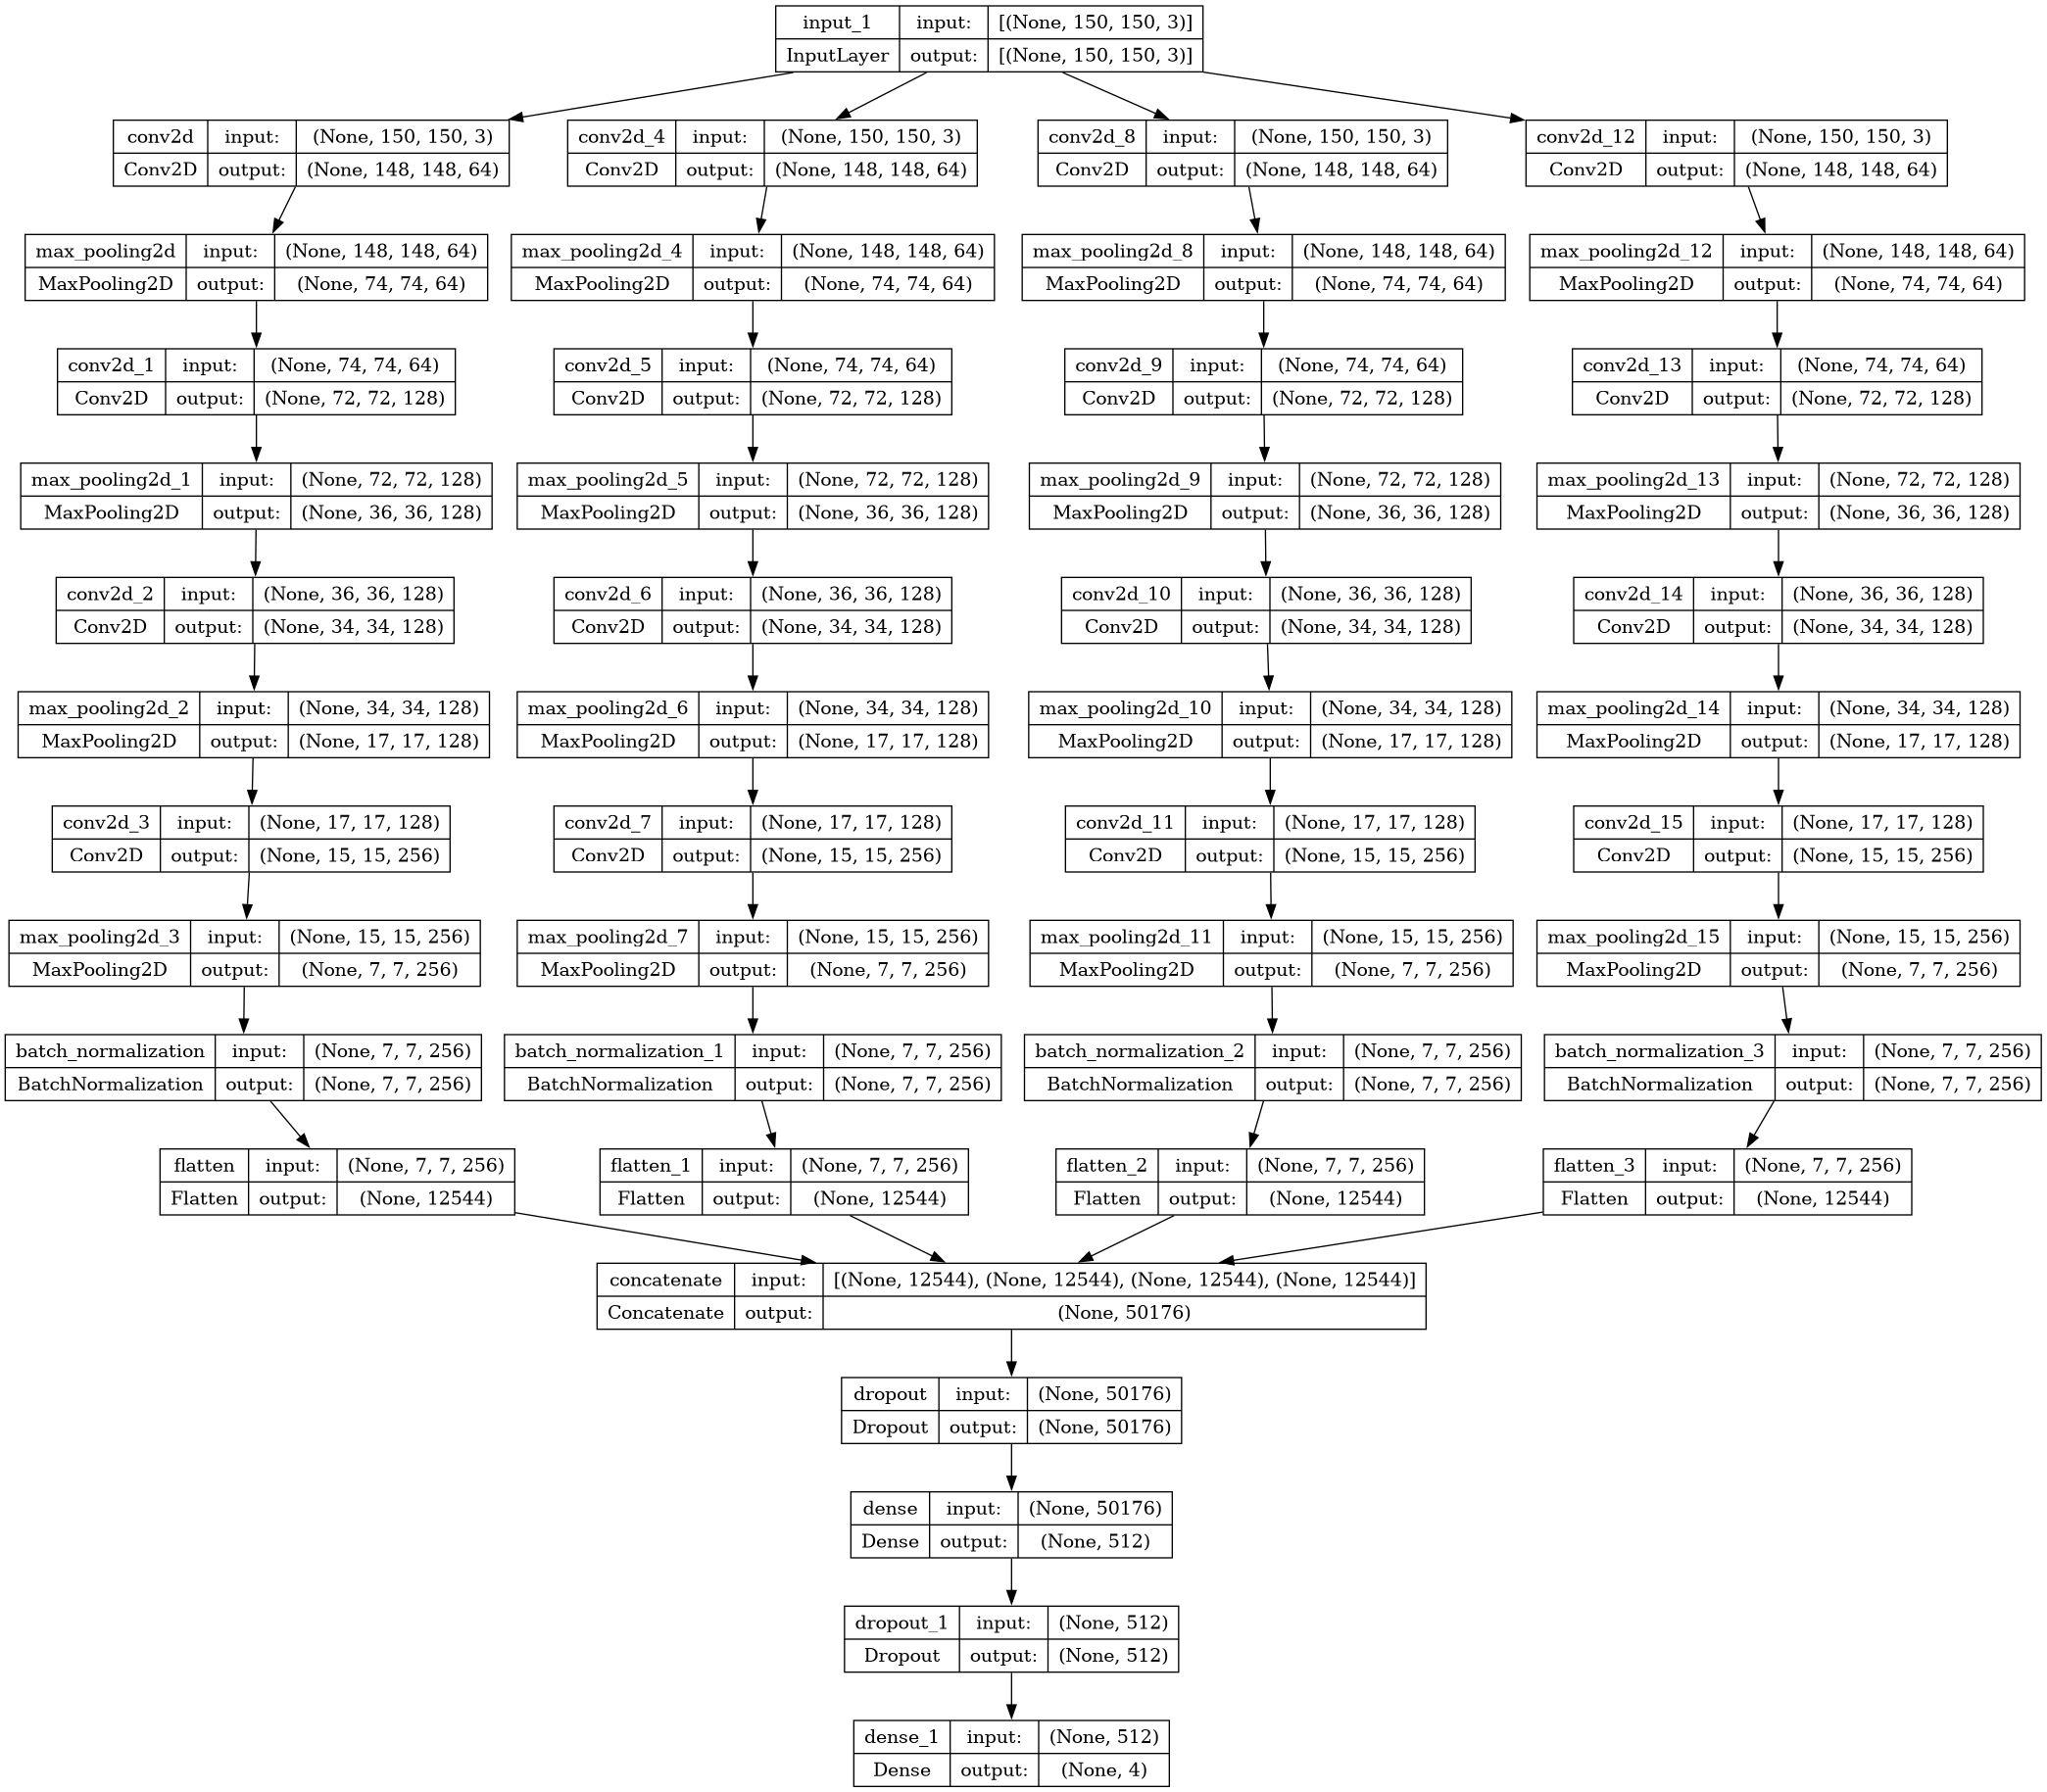

In [24]:
from tensorflow.keras.utils import plot_model

# Assuming you've created the model as shown in your code snippet

# Plot the model architecture to a file
plot_model(model, to_file='model_structure.png', show_shapes=True)


In [25]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 150, 150, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 148, 148, 64)         1792      ['input_1[0][0]']             
                                                                                                  
 conv2d_4 (Conv2D)           (None, 148, 148, 64)         1792      ['input_1[0][0]']             
                                                                                                  
 conv2d_8 (Conv2D)           (None, 148, 148, 64)         1792      ['input_1[0][0]']             
                                                                                              

In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout, concatenate
import keras
import matplotlib
from IPython.display import display, Image

# Define the input layer
visible = Input(shape=(150, 150, 3))

# Block 1
conv1_1 = Conv2D(64, kernel_size=3, activation='relu')(visible)
pool1_1 = MaxPooling2D(pool_size=(2, 2))(conv1_1)

conv1_2 = Conv2D(128, kernel_size=3, activation='relu')(pool1_1)
pool1_2 = MaxPooling2D(pool_size=(2, 2))(conv1_2)

conv1_3 = Conv2D(128, kernel_size=3, activation='relu')(pool1_2)
pool1_3 = MaxPooling2D(pool_size=(2, 2))(conv1_3)

conv1_4 = Conv2D(256, kernel_size=3, activation='relu')(pool1_3)
pool1_4 = MaxPooling2D(pool_size=(2, 2))(conv1_4)
batch_norm_1 = BatchNormalization()(pool1_4)

flat1 = Flatten()(batch_norm_1)

# Block 2
conv2_1 = Conv2D(64, kernel_size=3, activation='relu')(visible)
pool2_1 = MaxPooling2D(pool_size=(2, 2))(conv2_1)

conv2_2 = Conv2D(128, kernel_size=3, activation='relu')(pool2_1)
pool2_2 = MaxPooling2D(pool_size=(2, 2))(conv2_2)

conv2_3 = Conv2D(128, kernel_size=3, activation='relu')(pool2_2)
pool2_3 = MaxPooling2D(pool_size=(2, 2))(conv2_3)

conv2_4 = Conv2D(256, kernel_size=3, activation='relu')(pool2_3)
pool2_4 = MaxPooling2D(pool_size=(2, 2))(conv2_4)
batch_norm_2 = BatchNormalization()(pool2_4)

flat2 = Flatten()(batch_norm_2)

# Block 3
conv3_1 = Conv2D(64, kernel_size=3, activation='relu')(visible)
pool3_1 = MaxPooling2D(pool_size=(2, 2))(conv3_1)

conv3_2 = Conv2D(128, kernel_size=3, activation='relu')(pool3_1)
pool3_2 = MaxPooling2D(pool_size=(2, 2))(conv3_2)

conv3_3 = Conv2D(128, kernel_size=3, activation='relu')(pool3_2)
pool3_3 = MaxPooling2D(pool_size=(2, 2))(conv3_3)

conv3_4 = Conv2D(256, kernel_size=3, activation='relu')(pool3_3)
pool3_4 = MaxPooling2D(pool_size=(2, 2))(conv3_4)
batch_norm_3 = BatchNormalization()(pool3_4)

flat3 = Flatten()(batch_norm_3)

# Block 4
conv4_1 = Conv2D(64, kernel_size=3, activation='relu')(visible)
pool4_1 = MaxPooling2D(pool_size=(2, 2))(conv4_1)

conv4_2 = Conv2D(128, kernel_size=3, activation='relu')(pool4_1)
pool4_2 = MaxPooling2D(pool_size=(2, 2))(conv4_2)

conv4_3 = Conv2D(128, kernel_size=3, activation='relu')(pool4_2)
pool4_3 = MaxPooling2D(pool_size=(2, 2))(conv4_3)

conv4_4 = Conv2D(256, kernel_size=3, activation='relu')(pool4_3)
pool4_4 = MaxPooling2D(pool_size=(2, 2))(conv4_4)
batch_norm_4 = BatchNormalization()(pool4_4)

flat4 = Flatten()(batch_norm_4)

# # Merge the outputs of the convolutional blocks
merge = concatenate([flat1, flat2, flat3, flat4])
dropout_layer_1 = Dropout(0.25)(merge)

# Add a fully connected layer
hidden1 = Dense(512, activation='relu')(dropout_layer_1)
dropout_layer_3 = Dropout(0.5)(hidden1)

## Output layer
output = Dense(4, activation='softmax')(dropout_layer_3)
# Define the model
model = Model(inputs=visible, outputs=output)
# Assuming your last convolutional layer name is 'conv4_4'
last_conv_layer = 'conv4_4'

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img, heatmap, cam_path="cam.jpg", alpha=0.6):
    img = tf.reshape(img, shape=[150, 150, 3], name='y')
    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = matplotlib.cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

    # Save the superimposed image
    superimposed_img.save(cam_path)

    # Display Grad CAM
    display(Image(cam_path))
    return superimposed_img

# Assuming your training dataset is 'train_ds'
for images, labels in train_ds.take(1):
    image, label = images[0], labels[0]
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(train_ds.class_names[label.numpy()])
    plt.axis("off")
    plt.show()

    preds = model.predict(tf.expand_dims(image, axis=0), verbose=0)
    predicted_class = train_ds.class_names[np.argmax(preds[0])]
    print("Predicted class: ", predicted_class)

    heatmap = make_gradcam_heatmap(tf.expand_dims(image, axis=0), model, last_conv_layer)
    plt.matshow(heatmap)
    plt.show()
    save_and_display_gradcam(tf.expand_dims(image, axis=0), heatmap, alpha=0.8)

NameError: name 'train_ds' is not defined

In [ ]:
# Function to generate Grad-CAM heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [ ]:
# Function to save and display Grad-CAM
def save_and_display_gradcam(img, heatmap, cam_path="cam.jpg", alpha=0.6):
    img = tf.reshape(img, shape=[150, 150, 3], name='y')
    heatmap = np.uint8(255 * heatmap)
    jet = matplotlib.cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

    superimposed_img.save(cam_path)

    display(Image(cam_path))
    return superimposed_img

# Assuming model is already defined earlier
model = Model(inputs=visible, outputs=output)

# Assuming train_ds is already defined earlier
for images, labels in train_ds.take(1):
    image, label = images[0], labels[0]
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(train_ds.class_names[label])
    plt.axis("off")
    plt.show()

    preds = model.predict(tf.expand_dims(image, axis=0), verbose=0)
    predicted_class = train_ds.class_names[np.argmax(preds[0])]
    print("Predicted class: ", predicted_class)

    heatmap = make_gradcam_heatmap(tf.expand_dims(image, axis=0), model, last_conv_layer)
    plt.matshow(heatmap)
    plt.show()
    save_and_display_gradcam(tf.expand_dims(image, axis=0), heatmap, alpha=0.8)